In [3]:
import os; import pandas as pd
pd.options.display.float_format = '{:.3f}'.format
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
import numpy as np; import matplotlib.pyplot as plt
import gurobipy as gp; from gurobipy import GRB
from itertools import product; from tqdm import tqdm
import importlib
import functions_utils; import functions_data
import functions_optimize; import functions_eval
importlib.reload(functions_data); importlib.reload(functions_optimize)
importlib.reload(functions_eval); importlib.reload(functions_utils)
from functions_utils import *; from functions_data import *
from functions_optimize import *; from functions_eval import *
import time

✅ Figure successfully saved to:
C:/Users/jangseohyun/SynologyDrive/workspace/opt-pricing\fig_aggprof.pdf

===== Average Profit Comparison =====
Average Individual      : 5,328.76 (k$)
Average Decentralized   : 6,190.70 (k$)
Average Centralized     : 6,191.60 (k$)
Decentralized - Individual : 861.94 (k$)  (+16.18%)
Centralized - Decentralized: 0.89 (k$)  (+0.01%)


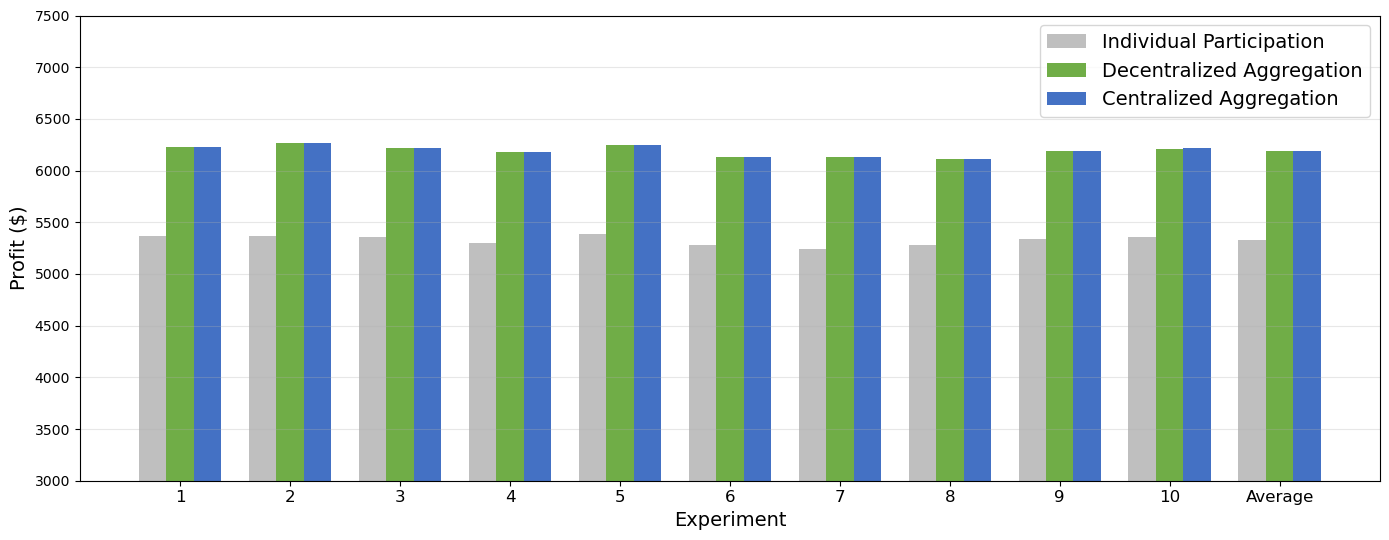

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Provided data
seeds = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

individual = [5371440.368488981, 5367257.42593928, 5361630.956006297, 5297197.647658327,  5389458.091606238, 5279634.097175172, 5242593.5603676485, 5278460.430907839, 5340539.57758688, 5359399.882094547]
decentralized = [6223374.007056907, 6265661.102292818, 6217264.682383419, 6182010.610303213, 6247008.283538688, 6131504.601715936, 6126731.20700144, 6115893.4333082875, 6184701.570175273, 6212895.72]
centralized = [6224446.009517045, 6265426.28014021, 6217394.603183249, 6182976.300511132, 6249826.863872521, 6131433.210485378, 6128447.216317896, 6116217.426137356, 6185328.456297234, 6214487.26831143]


# --- 1. Calculate and append the average values ---
# Calculate the average for each list
avg_individual = np.mean(np.array(individual)/1000)
avg_decentralized = np.mean(np.array(decentralized)/1000)
avg_centralized = np.mean(np.array(centralized)/1000)

# Append the averages to the end of the original data lists
individual_with_avg = [x/1000 for x in individual] + [avg_individual]
decentralized_with_avg = [x/1000 for x in decentralized] + [avg_decentralized]
centralized_with_avg = [x/1000 for x in centralized] + [avg_centralized]

# --- 2. Update the x-axis labels ---
# Add 'Average' as the last label on the x-axis
seeds_with_avg_label = [str(s) for s in seeds] + ['Average']


# --- 3. Plotting ---
# Set the positions for the bars (now 11 positions)
x = np.arange(len(seeds_with_avg_label))
width = 0.25

fig, ax = plt.subplots(figsize=(14, 5.5))

# Plot the bars for each category using the new extended data
rects1 = ax.bar(x - width, individual_with_avg, width, label='Individual Participation', color='#BFBFBF')
rects2 = ax.bar(x, decentralized_with_avg, width, label='Decentralized Aggregation', color='#70AD47')
rects3 = ax.bar(x + width, centralized_with_avg, width, label='Centralized Aggregation', color='#4471C4')

# # --- 4. Add a black edge to the average bars to make them stand out ---
# for i in range(3):
#     bar_group = [rects1, rects2, rects3]
#     bar_group[i][-1].set_edgecolor('black')
#     bar_group[i][-1].set_linewidth(1.5)

# Add text for labels, title and axes ticks
ax.set_ylabel('Profit ($)', fontsize=14)
ax.set_ylim(3000, 7500)
ax.set_xlabel('Experiment', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(seeds_with_avg_label, fontsize=12) # Use the new labels
ax.legend(fontsize=14, loc='upper right')

ax.grid(axis='y', alpha=0.3)
fig.tight_layout()
save_dir = r"C:/Users/jangseohyun/SynologyDrive/workspace/opt-pricing"
os.makedirs(save_dir, exist_ok=True)  # 폴더 없으면 생성
save_path = os.path.join(save_dir, "fig_aggprof.pdf")

# --- 저장 및 표시 ---
plt.savefig(save_path, format='pdf', bbox_inches='tight')
print(f"✅ Figure successfully saved to:\n{save_path}")

diff_dec_vs_ind_k = avg_decentralized - avg_individual
diff_cent_vs_dec_k = avg_centralized - avg_decentralized

diff_dec_vs_ind_pct = (avg_decentralized - avg_individual) / avg_individual * 100
diff_cent_vs_dec_pct = (avg_centralized - avg_decentralized) / avg_decentralized * 100

print("\n===== Average Profit Comparison =====")
print(f"Average Individual      : {avg_individual:,.2f} (k$)")
print(f"Average Decentralized   : {avg_decentralized:,.2f} (k$)")
print(f"Average Centralized     : {avg_centralized:,.2f} (k$)")
print(
    f"Decentralized - Individual : {diff_dec_vs_ind_k:,.2f} (k$)  ({diff_dec_vs_ind_pct:+.2f}%)"
)
print(
    f"Centralized - Decentralized: {diff_cent_vs_dec_k:,.2f} (k$)  ({diff_cent_vs_dec_pct:+.2f}%)"
)

✅ Figure successfully saved to:
C:\Users\jangseohyun\SynologyDrive\workspace\opt-pricing\fig_price.pdf


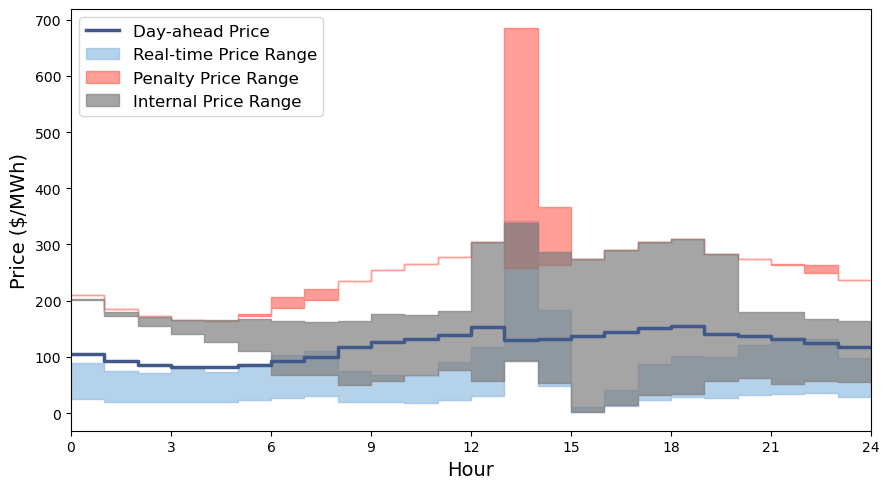

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ===============================
# 1. Figure 생성
# ===============================
plt.figure(figsize=(9, 5))
ax = plt.gca()

i = 7  # SEED = 7

# ===============================
# 2. 데이터 로드
# ===============================
filename = f'./solution/optimization_results_{i}.csv'
df = pd.read_csv(filename)

if 'P_IN' not in df.columns and 'Internal_Price' in df.columns:
    df.rename(columns={'Internal_Price': 'P_IN'}, inplace=True)

# ===============================
# 3. 이상 시나리오 제거
# ===============================
df['min_bound'] = df[['P_DA', 'P_RT', 'P_PN']].min(axis=1)
df['max_bound'] = df[['P_DA', 'P_RT', 'P_PN']].max(axis=1)

out_of_bounds = df[
    (df['P_IN'] < df['min_bound'] - 1) |
    (df['P_IN'] > df['max_bound'] + 1)
]
scenarios_to_remove = out_of_bounds['s'].unique()
filtered_df = df[~df['s'].isin(scenarios_to_remove)].copy()

# ===============================
# 4. Step plot용 시간 벡터
# ===============================
t_unique = np.sort(filtered_df['t'].unique()).astype(int)
t_edges = np.append(t_unique, t_unique[-1] + 1)

# ===============================
# 5. 값 구성 (step용)
# ===============================
# DA
p_da = (
    filtered_df[['t', 'P_DA']]
    .drop_duplicates()
    .sort_values('t')
    .set_index('t')
    .reindex(t_unique)['P_DA']
    .values
)
p_da_step = np.append(p_da, p_da[-1])

# RT
prt = filtered_df.groupby('t')['P_RT'].agg(['min', 'max']).reindex(t_unique)
prt_min = np.append(prt['min'].values, prt['min'].values[-1])
prt_max = np.append(prt['max'].values, prt['max'].values[-1])

# PN
ppn = filtered_df.groupby('t')['P_PN'].agg(['min', 'max']).reindex(t_unique)
ppn_min = np.append(ppn['min'].values, ppn['min'].values[-1])
ppn_max = np.append(ppn['max'].values, ppn['max'].values[-1])

# Internal
pin = filtered_df.groupby('t')['P_IN'].agg(['min', 'max']).reindex(t_unique)
pin_min = np.append(pin['min'].values, pin['min'].values[-1])
pin_max = np.append(pin['max'].values, pin['max'].values[-1])

ax.step(t_edges, p_da_step, where='post', color='#415989', linewidth=2.5, label='Day-ahead Price')
ax.fill_between(t_edges, prt_min, prt_max, step='post',color='#85B4DF', alpha=0.6, label='Real-time Price Range')
ax.fill_between(t_edges, ppn_min, ppn_max, step='post',color='#FF5E51', alpha=0.6, label='Penalty Price Range')
ax.fill_between(t_edges, pin_min, pin_max, step='post',color='#7F7F7F', alpha=0.7, label='Internal Price Range')
# ax.fill_between(t_edges, prt_min, prt_max, step='post', color='#85B4DF', alpha=0.5, edgecolor='#85B4DF', linewidth=2, label='Real-time Price Range')
# ax.fill_between(t_edges, ppn_min, ppn_max, step='post', color='#FF5E51', alpha=0.5, edgecolor='#FF5E51', linewidth=2, label='Penalty Price Range')
# ax.fill_between(t_edges, pin_min, pin_max, step='post', color='#7F7F7F', alpha=0.5, edgecolor='#7F7F7F', linewidth=2, label='Internal Price Range')
ax.set_xlabel('Hour', fontsize=14)
ax.set_ylabel('Price ($/MWh)', fontsize=14)
ax.set_xlim(t_unique[0], t_unique[-1] + 1)
ax.set_xticks(np.arange(0, 25, 3))
ax.legend(fontsize=12, loc = 'upper left')
plt.tight_layout()

save_dir = r"C:\Users\jangseohyun\SynologyDrive\workspace\opt-pricing"
os.makedirs(save_dir, exist_ok=True)
save_path = os.path.join(save_dir, "fig_price.pdf")

plt.savefig(save_path, format='pdf', bbox_inches='tight')
print(f"✅ Figure successfully saved to:\n{save_path}")

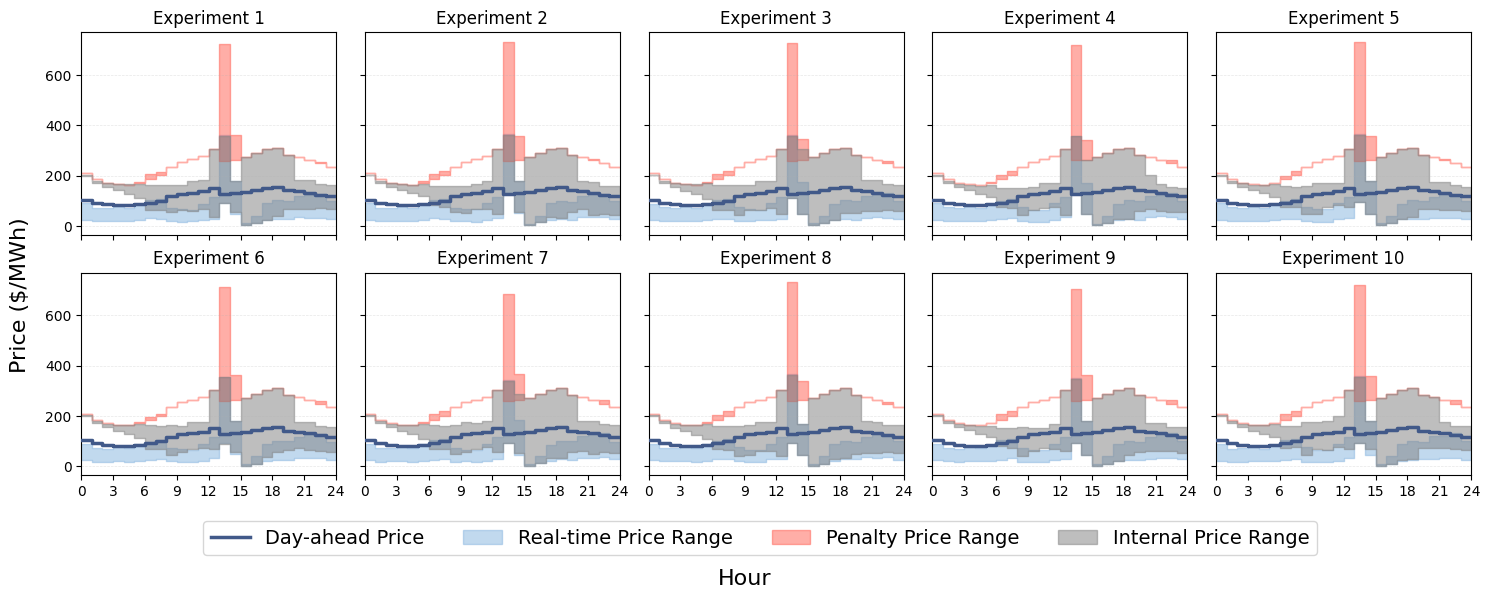

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

fig, axes = plt.subplots(2, 5, figsize=(15, 6), sharex=True, sharey=True)

for i in range(1, 11):
    row = (i - 1) // 5
    col = (i - 1) % 5
    ax = axes[row, col]

    try:
        filename = f'./solution/optimization_results_{i}.csv'
        df = pd.read_csv(filename)

        if 'P_IN' not in df.columns and 'Internal_Price' in df.columns:
            df.rename(columns={'Internal_Price': 'P_IN'}, inplace=True)

        df['min_bound'] = df[['P_DA', 'P_RT', 'P_PN']].min(axis=1)
        df['max_bound'] = df[['P_DA', 'P_RT', 'P_PN']].max(axis=1)
        out_of_bounds_rows = df[(df['P_IN'] < df['min_bound'] - 1) | (df['P_IN'] > df['max_bound'] + 1)]
        scenarios_to_remove = out_of_bounds_rows['s'].unique()
        filtered_df = df[~df['s'].isin(scenarios_to_remove)].copy()

        t_unique = np.sort(filtered_df['t'].unique()).astype(int)
        t_edges = np.append(t_unique, t_unique[-1] + 1)  # 0..24 같은 경계

        p_da = (filtered_df[['t', 'P_DA']]
                .drop_duplicates()
                .sort_values('t')
                .set_index('t')
                .reindex(t_unique)['P_DA']
                .values)
        p_da_step = np.append(p_da, p_da[-1])

        prt = filtered_df.groupby('t')['P_RT'].agg(['min', 'max']).reindex(t_unique)
        prt_min_step = np.append(prt['min'].values, prt['min'].values[-1])
        prt_max_step = np.append(prt['max'].values, prt['max'].values[-1])

        ppn = filtered_df.groupby('t')['P_PN'].agg(['min', 'max']).reindex(t_unique)
        ppn_min_step = np.append(ppn['min'].values, ppn['min'].values[-1])
        ppn_max_step = np.append(ppn['max'].values, ppn['max'].values[-1])

        pin = filtered_df.groupby('t')['P_IN'].agg(['min', 'max']).reindex(t_unique)
        pin_min_step = np.append(pin['min'].values, pin['min'].values[-1])
        pin_max_step = np.append(pin['max'].values, pin['max'].values[-1])

        ax.step(t_edges, p_da_step, where='post', linestyle='-', color='#415989',
                label='Day-ahead Price', linewidth=2.5, zorder=10)

        ax.fill_between(t_edges, prt_min_step, prt_max_step, step='post',
                        color='#85B4DF', alpha=0.5, label='Real-time Price Range')

        ax.fill_between(t_edges, ppn_min_step, ppn_max_step, step='post',
                        color='#FF5E51', alpha=0.5, label='Penalty Price Range')

        ax.fill_between(t_edges, pin_min_step, pin_max_step, step='post',
                        color='#7F7F7F', alpha=0.5, label='Internal Price Range')

        ax.set_title(f'Experiment {i}', fontsize=12)
        ax.grid(True, which='both', linestyle='--', linewidth=0.5, axis='y', alpha=0.3)
        ax.set_xlim(t_unique[0], t_unique[-1] + 1)
        ax.set_xticks(np.arange(0, 25, 3))

    except FileNotFoundError:
        ax.text(0.5, 0.5, f'File {i} not found', ha='center', va='center')
        ax.set_title(f'Experiment {i}', fontsize=12, color='red')
    except Exception:
        ax.text(0.5, 0.5, f'Error plotting file {i}', ha='center', va='center')
        ax.set_title(f'Experiment {i}', fontsize=12, color='red')

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=4,
           bbox_to_anchor=(0.51, 0.05), fontsize=14)

fig.supxlabel('Hour', fontsize=16)
fig.supylabel('Price ($/MWh)', fontsize=16, x=0.01)

plt.tight_layout()
plt.subplots_adjust(bottom=0.2)

# save_dir = r"C:\Users\jangseohyun\SynologyDrive\workspace\opt-pricing"
# os.makedirs(save_dir, exist_ok=True)
# save_path = os.path.join(save_dir, "fig_price.pdf")

# plt.savefig(save_path, format='pdf', bbox_inches='tight')
# print(f"✅ Figure successfully saved to:\n{save_path}")

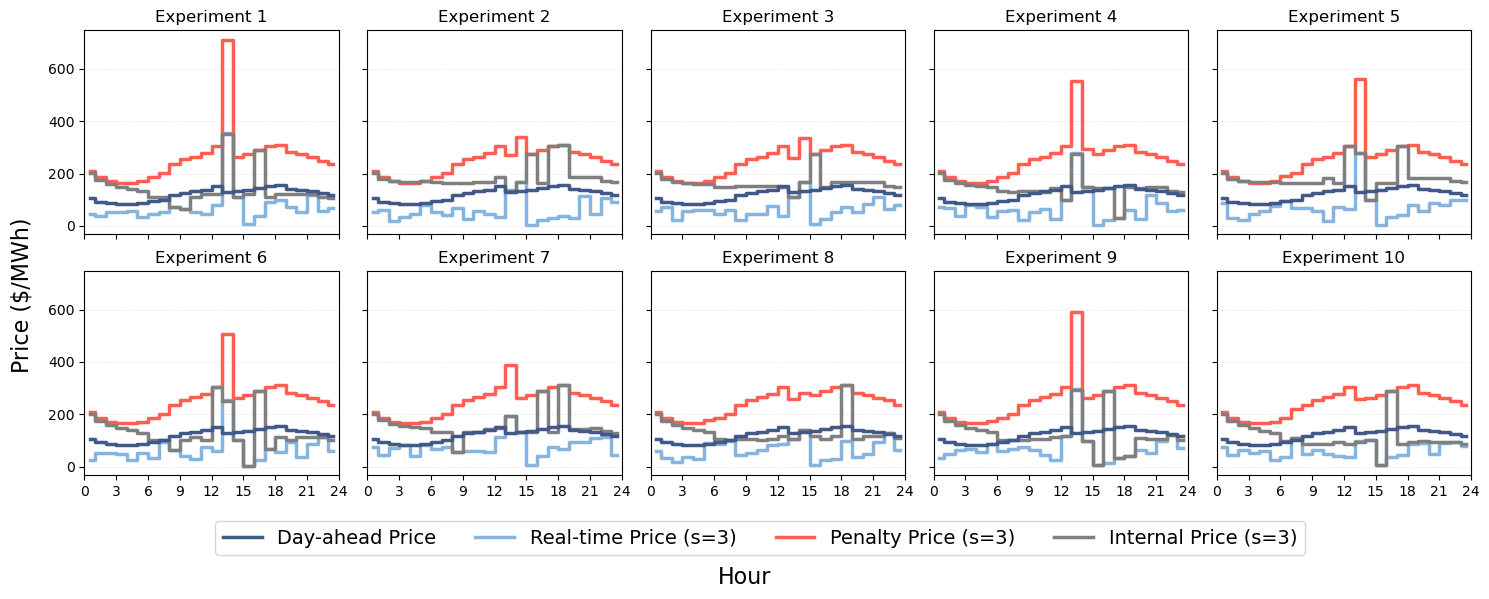

In [18]:
import pandas as pd; import matplotlib.pyplot as plt; import numpy as np; import os

TARGET_S = 3

fig, axes = plt.subplots(2, 5, figsize=(15, 6), sharex=True, sharey=True)
for i in range(1, 11):
    row = (i - 1) // 5
    col = (i - 1) % 5
    ax = axes[row, col]

    try:
        filename = f"./solution/optimization_results_{i}.csv"
        df = pd.read_csv(filename)

        if "P_IN" not in df.columns and "Internal_Price" in df.columns:
            df.rename(columns={"Internal_Price": "P_IN"}, inplace=True)

        scen_df = df[df["s"] == TARGET_S].copy()

        if scen_df.empty:
            ax.text(
                0.5, 0.5, f"Scenario {TARGET_S} not found", ha="center", va="center"
            )
            ax.set_title(f"Experiment {i}", fontsize=12, color="red")
            ax.set_xlim(0, 24)
            ax.set_xticks(np.arange(0, 25, 3))
            continue

        t_unique = np.sort(scen_df["t"].unique())
        t_mid = t_unique + 0.5

        p_da_data = df[["t", "P_DA"]].drop_duplicates().sort_values("t")
        p_da_data = p_da_data[p_da_data["t"].isin(t_unique)].sort_values("t")
        y_da = p_da_data["P_DA"].values

        scen_sorted = scen_df.sort_values("t")
        y_rt = scen_sorted["P_RT"].values
        y_pn = scen_sorted["P_PN"].values
        y_in = scen_sorted["P_IN"].values

        ax.step(
            t_mid,
            y_da,
            where="mid",
            color="#415989",
            label="Day-ahead Price",
            linewidth=2.5,
            zorder=10,
        )
        ax.step(
            t_mid,
            y_rt,
            where="mid",
            color="#85B4DF",
            label=f"Real-time Price (s={TARGET_S})",
            linewidth=2.5,
        )
        ax.step(
            t_mid,
            y_pn,
            where="mid",
            color="#FF5E51",
            label=f"Penalty Price (s={TARGET_S})",
            linewidth=2.5,
        )
        ax.step(
            t_mid,
            y_in,
            where="mid",
            color="#7F7F7F",
            label=f"Internal Price (s={TARGET_S})",
            linewidth=2.5,
        )

        ax.set_title(f"Experiment {i}", fontsize=12)
        ax.grid(True, which="both", linestyle="--", linewidth=0.5, axis="y", alpha=0.3)
        ax.set_xlim(0, 24)
        ax.set_xticks(np.arange(0, 25, 3))

    except FileNotFoundError:
        ax.text(0.5, 0.5, f"File {i} not found", ha="center", va="center")
        ax.set_title(f"Experiment {i}", fontsize=12, color="red")
    except Exception as e:
        ax.text(0.5, 0.5, f"Error plotting file {i}", ha="center", va="center")
        ax.set_title(f"Experiment {i}", fontsize=12, color="red")

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=4, bbox_to_anchor=(0.51, 0.05), fontsize=14)
fig.supxlabel("Hour", fontsize=16); fig.supylabel("Price ($/MWh)", fontsize=16, x=0.01)
plt.tight_layout(); plt.subplots_adjust(bottom=0.2)

In [23]:
import os; import pandas as pd
pd.options.display.float_format = '{:.3f}'.format
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
import numpy as np; import matplotlib.pyplot as plt
import gurobipy as gp; from gurobipy import GRB
from itertools import product; from tqdm import tqdm
import importlib
import functions_utils; import functions_data
import functions_optimize; import functions_eval
importlib.reload(functions_data); importlib.reload(functions_optimize)
importlib.reload(functions_eval); importlib.reload(functions_utils)
from functions_utils import *; from functions_data import *
from functions_optimize import *; from functions_eval import *
import time

S = 100
LEVEL = "high"
SEED = 1

generation_data, I, T = load_generation_data(date_filter="2022-07-18")
R, P_RT, K, K0, _, _, CRATE, DRATE = load_parameters(I, T, generation_data, S, LEVEL, SEED)
P_DA, P_PN = load_price_data(P_RT)
INEFF = 0.95

def plot_rt_scenarios(P_RT):
    # # plot_scenarios_for_generator(R,1)
    T, S = P_RT.shape
    hours = np.arange(0.5, T + 0.5)  # 0.5~23.5

    plt.figure(figsize=(10,5))

    for s in range(S):
        plt.plot(hours, P_RT[:, s], linestyle='-', alpha=0.2)

    mean_curve = np.mean(P_RT, axis=1)
    plt.plot(hours, mean_curve, color="#415989", linewidth=3, label="Original Data")

    plt.xlabel("Hour", fontsize=18)
    plt.ylabel("Price ($/MWh)", fontsize=18)
    plt.xlim(0, 24)
    plt.xticks(range(0, 25), fontsize=12)
    plt.legend(loc="upper left", fontsize=18)
    plt.tight_layout()

    save_dir = r"C:\Users\jangseohyun\SynologyDrive\workspace\opt-pricing"
    os.makedirs(save_dir, exist_ok=True)
    save_path = os.path.join(save_dir, "fig_pricenoise.pdf")

    plt.savefig(save_path, format='pdf', bbox_inches='tight')
    print(f"✅ Figure successfully saved to:\n{save_path}")


def plot_scenarios_for_generator(R, i):
    T = R.shape[1]
    S = R.shape[2]
    hours = np.arange(0.5, T + 0.5)  # 0.5~23.5

    plt.figure(figsize=(10,5))

    for s in range(S):
        plt.plot(hours, R[i, :, s]*1000, linestyle='-', alpha=0.2)
    mean_curve = np.mean(R[i, :, :]*1000, axis=1)
    plt.plot(hours, mean_curve, color="#415989", linewidth=3, label="Original Data")

    plt.xlabel("Hour", fontsize=18)
    plt.ylabel("Electricity Generated (kW)", fontsize=18)
    plt.xlim(0, 24)
    plt.xticks(range(0, 25), fontsize=12)
    plt.legend(loc="upper left", fontsize=18)
    plt.tight_layout()

    save_dir = r"C:\Users\jangseohyun\SynologyDrive\workspace\opt-pricing"
    os.makedirs(save_dir, exist_ok=True)  # 폴더 없으면 생성
    save_path = os.path.join(save_dir, "fig_generationnoise.pdf")

    # --- 저장 및 표시 ---
    plt.savefig(save_path, format='pdf', bbox_inches='tight')
    print(f"✅ Figure successfully saved to:\n{save_path}")

✅ 총 10개 파일을 불러왔습니다: 1033.csv, 1818.csv, 2502.csv, 2503.csv, 2634.csv, 2698.csv, 2816.csv, 545.csv, 665.csv, 690.csv
📊 데이터 Shape: I=10, T=24, S=100
✅ 시뮬레이션 초기화 완료: S=100, Randomness='high', Random Seed=1, M1=3649.20, M2=9627.43
   - 개별 K 값: [200. 200. 400. 600. 100. 600. 300. 200. 300. 200.]


✅ Figure successfully saved to:
C:\Users\jangseohyun\SynologyDrive\workspace\opt-pricing\fig_pricenoise.pdf


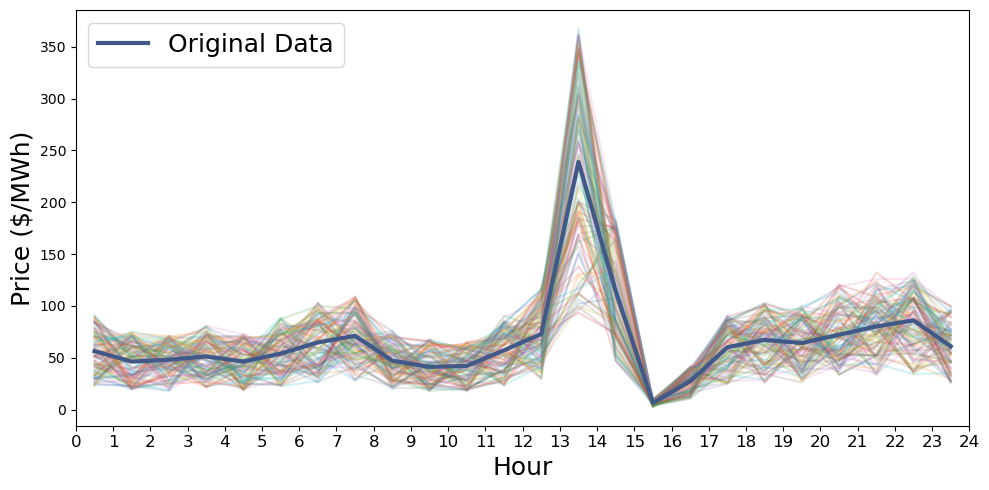

In [24]:
plot_rt_scenarios(P_RT)

✅ Figure successfully saved to:
C:\Users\jangseohyun\SynologyDrive\workspace\opt-pricing\fig_generationnoise.pdf


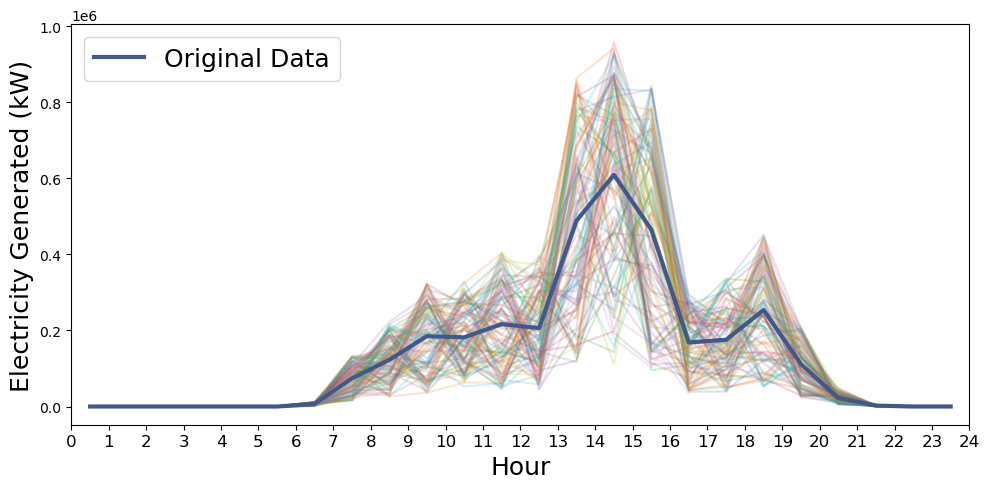

In [25]:
plot_scenarios_for_generator(R, 1)

✅ Figure successfully saved to:
C:\Users\jangseohyun\SynologyDrive\workspace\opt-pricing\fig_indquant.pdf


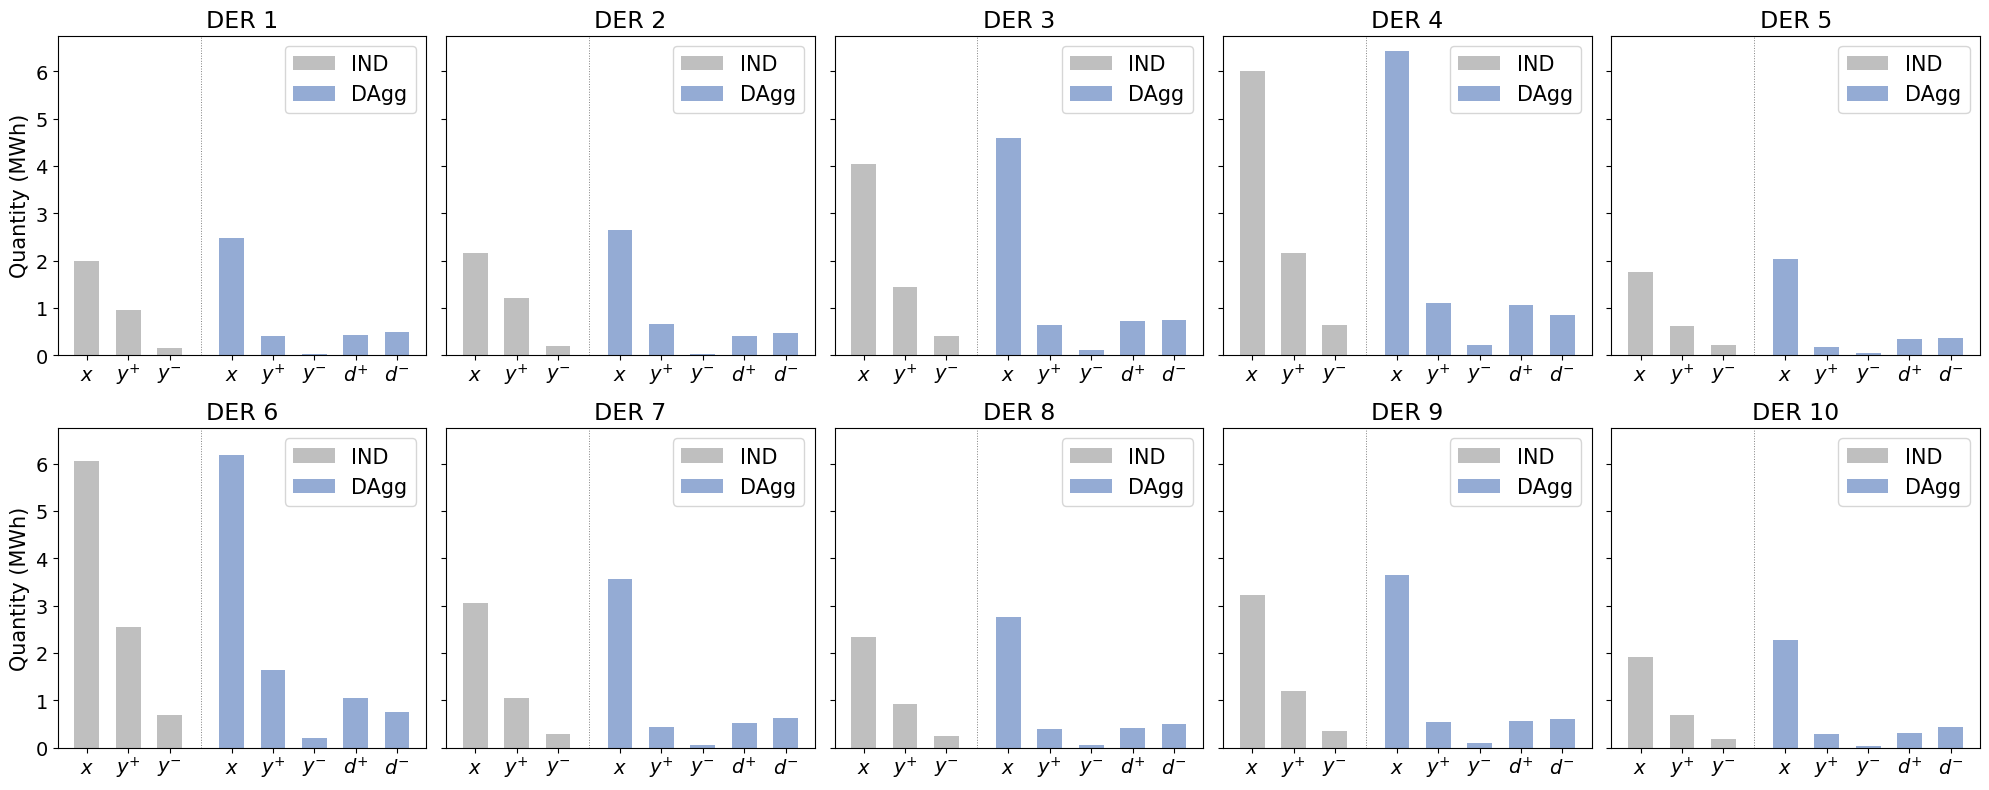

In [20]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RESULT_DIR = "./results_csv"
SEEDS = [1, 2, 3, 4, 5, 6, 7, 8, 9, 25]
PLAYERS = list(range(10))

ind_vars = ["x_ind", "yp_ind", "ym_ind"]
re_vars  = ["x_re", "yp_re", "ym_re", "dp_re", "dm_re"]

ind_x = np.arange(len(ind_vars))          # [0,1,2]
gap = 0.5
re_x  = np.arange(len(re_vars)) + ind_x[-1] + gap + 1

# =========================
# RowSum 로드 함수
# =========================
def load_rowsum(varname, seed):
    path = os.path.join(RESULT_DIR, f"{varname}_seed{seed}.csv")
    df = pd.read_csv(path, encoding="utf-8-sig")
    df = df.set_index(df.columns[0])
    return df["RowSum"]

# =========================
# 시드 평균 계산 (→ MWh)
# =========================
mean_vals = {}
for var in ind_vars + re_vars:
    rows = []
    for sd in SEEDS:
        rs = load_rowsum(var, sd)
        rows.append([rs.loc[f"i{i}"] / 1000.0 for i in PLAYERS])
    mean_vals[var] = np.mean(rows, axis=0)

# =========================
# Plot
# =========================
fig, axes = plt.subplots(2, 5, figsize=(20, 8), sharey=True)
axes = axes.flatten()

xtick_positions = list(ind_x) + list(re_x)
xtick_labels = [
    r"$x$",
    r"$y^{+}$",
    r"$y^{-}$",
    r"$x$",
    r"$y^{+}$",
    r"$y^{-}$",
    r"$d^{+}$",
    r"$d^{-}$",
]


for idx, i in enumerate(PLAYERS):
    ax = axes[idx]

    # IND
    ind_y = [mean_vals[v][i] for v in ind_vars]
    ax.bar(
        ind_x, ind_y,
        width=0.6,
        color="#BFBFBF",
        label="IND"
    )

    # RE
    re_y = [mean_vals[v][i] for v in re_vars]
    ax.bar(re_x, re_y, width=0.6, color="#94ABD4", label="DAgg")

    # Formatting
    ax.set_title(f"DER {i+1}", fontsize=17)
    ax.set_xticks(xtick_positions)
    ax.set_xticklabels(xtick_labels, ha="center", fontsize=14)
    ax.tick_params(axis="x", pad=6)
    for lab in ax.get_xticklabels():
        lab.set_va("center")
        lab.set_y(-0.02)

    ax.tick_params(axis='y', labelsize=14)
    ax.axvline(ind_x[-1] + 0.75, linestyle=":", linewidth=0.7, color="gray")

    if idx % 5 == 0:
        ax.set_ylabel("Quantity (MWh)", fontsize=15)

    # ✅ legend를 각 subplot 안에
    ax.legend(
        loc="upper right",
        ncol=1,          # 세로 두 줄 (IND / DAgg)
        fontsize=15,
        # frameon=False
    )

fig.tight_layout()
save_dir = r"C:\Users\jangseohyun\SynologyDrive\workspace\opt-pricing"
os.makedirs(save_dir, exist_ok=True)  # 폴더 없으면 생성
save_path = os.path.join(save_dir, "fig_indquant.pdf")

# --- 저장 및 표시 ---
plt.savefig(save_path, format='pdf', bbox_inches='tight')
print(f"✅ Figure successfully saved to:\n{save_path}")

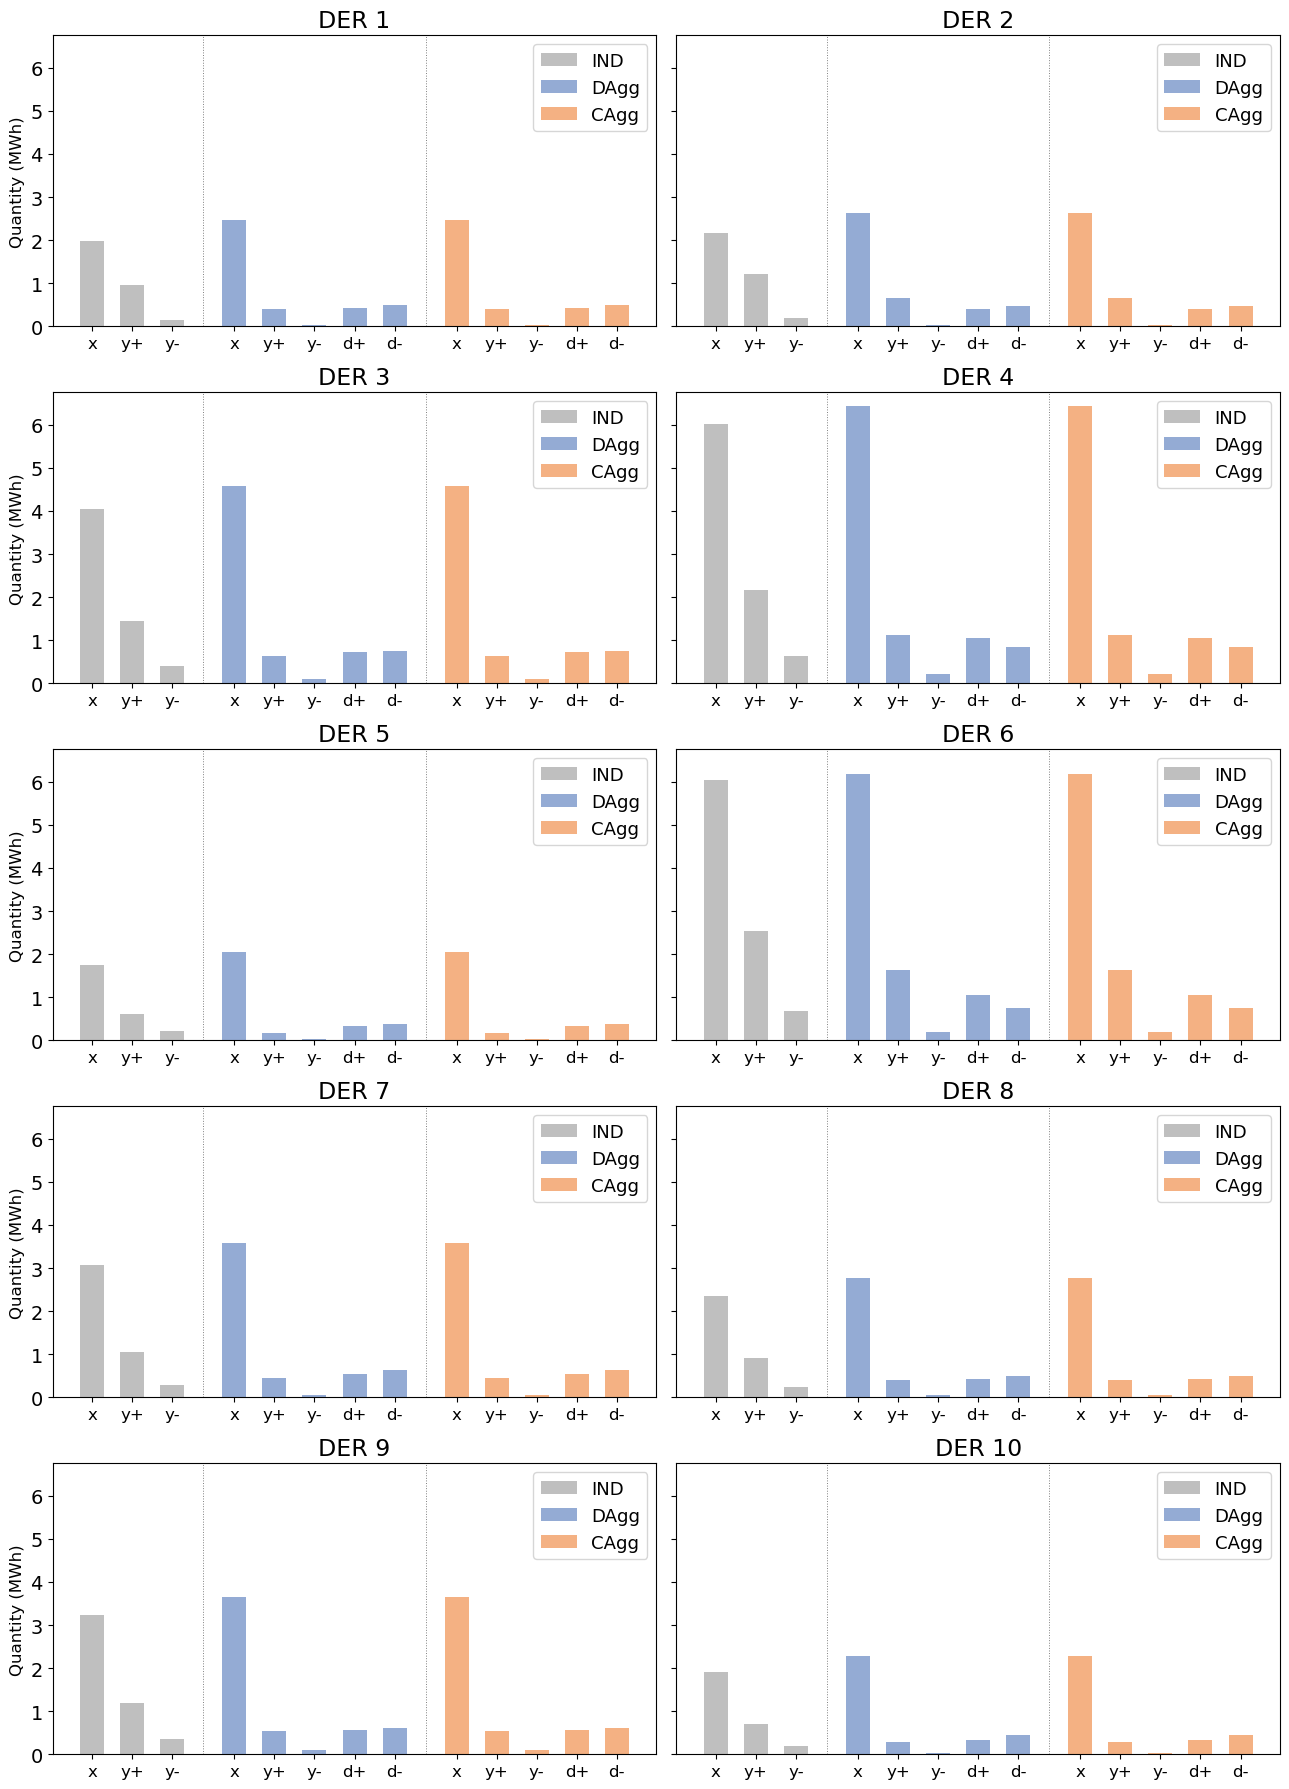

In [24]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RESULT_DIR = "./results_csv"
SEEDS = [1, 2, 3, 4, 5, 6, 7, 8, 9, 25]
PLAYERS = list(range(10))

# -------------------------
# 변수 세트
# -------------------------
ind_vars = ["x_ind", "yp_ind", "ym_ind"]  # 3개
agg_vars = ["x_re", "yp_re", "ym_re", "dp_re", "dm_re"]  # 5개 (Decentralized)
hol_vars = ["x_hol", "yp_hol", "ym_hol", "dp_hol", "dm_hol"]  # 5개 (Centralized)

# -------------------------
# x 위치 (3 그룹)
# -------------------------
ind_x = np.arange(len(ind_vars))  # [0,1,2]

gap1 = 0.55
agg_x = np.arange(len(agg_vars)) + ind_x[-1] + gap1 + 1

gap2 = 0.55
hol_x = np.arange(len(hol_vars)) + agg_x[-1] + gap2 + 1

# xtick (12개)
xtick_positions = list(ind_x) + list(agg_x) + list(hol_x)
xtick_labels = (
    ["x", "y+", "y-"] + ["x", "y+", "y-", "d+", "d-"] + ["x", "y+", "y-", "d+", "d-"]
)


# =========================
# RowSum 로드
# =========================
def load_rowsum(varname, seed):
    path = os.path.join(RESULT_DIR, f"{varname}_seed{seed}.csv")
    df = pd.read_csv(path, encoding="utf-8-sig")
    df = df.set_index(df.columns[0])
    return df["RowSum"]


# =========================
# 시드 평균 계산 (→ MWh)
# =========================
mean_vals = {}
all_vars = ind_vars + agg_vars + hol_vars

for var in all_vars:
    rows = []
    for sd in SEEDS:
        rs = load_rowsum(var, sd)
        rows.append([rs.loc[f"i{i}"] / 1000.0 for i in PLAYERS])  # kWh -> MWh
    mean_vals[var] = np.mean(rows, axis=0)

# =========================
# Plot
# =========================
fig, axes = plt.subplots(5, 2, figsize=(13, 18), sharey=True)
axes = axes.flatten()

for idx, i in enumerate(PLAYERS):
    ax = axes[idx]

    # IND
    ind_y = [mean_vals[v][i] for v in ind_vars]
    ax.bar(ind_x, ind_y, width=0.6, color="#BFBFBF", label="IND")

    # DAgg (Decentralized)
    agg_y = [mean_vals[v][i] for v in agg_vars]
    ax.bar(agg_x, agg_y, width=0.6, color="#94ABD4", label="DAgg")

    # HOL (Centralized)
    hol_y = [mean_vals[v][i] for v in hol_vars]
    ax.bar(hol_x, hol_y, width=0.6, color="#F4B183", label="CAgg")

    # Formatting
    ax.set_title(f"DER {i+1}", fontsize=17)
    ax.set_xticks(xtick_positions)
    ax.set_xticklabels(xtick_labels, ha="center", fontsize=12)
    ax.tick_params(axis="y", labelsize=14)

    # 그룹 구분선 (IND | DAgg | HOL)
    ax.axvline(ind_x[-1] + (gap1 + 1) / 2, linestyle=":", linewidth=0.7, color="gray")
    ax.axvline(agg_x[-1] + (gap2 + 1) / 2, linestyle=":", linewidth=0.7, color="gray")

    if idx % 2 == 0:
        ax.set_ylabel("Quantity (MWh)", fontsize=12)

    # legend (각 subplot 내부, 세로 3줄)
    ax.legend(loc="upper right", ncol=1, fontsize=13)

fig.tight_layout()

# =========================
# Save
# =========================
# save_dir = r"C:\Users\jangseohyun\SynologyDrive\workspace\opt-pricing"
# os.makedirs(save_dir, exist_ok=True)
# save_path = os.path.join(save_dir, "fig_indquant_3models.pdf")

# plt.savefig(save_path, format="pdf", bbox_inches="tight")
# print(f"✅ Figure successfully saved to:\n{save_path}")

plt.show()